# Structural viral protein isoelectric points by family — WATL wet + dry 

In [35]:
REV = "/Users/skoog/Desktop"

FAA_DIR      = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit"
WATL_SUMMARY = (f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/"
                f"WATL_wet_dry_viruses_uniqueIDs_virus_summary.tsv")   

PI_CSV         = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_structural_viral_proteins_WATL_wet_dry_revisions_besthit.csv"
MERGED_CSV     = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_with_taxonomy_WATL_wet_dry_revisions_besthit.csv"
FIG_FAMILY_SVG = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_family_WATL_wet_dry_revisions_besthit.svg"
FIG_FAMILY_PNG = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_family_WATL_wet_dry_revisions_besthit.png"
FIG_ORDER_SVG  = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_order_WATL_wet_dry_revisions_besthit.svg"
FIG_ORDER_PNG  = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_order_WATL_wet_dry_revisions_besthit.png"

PI_CENTER = 7.0   

# Enveloped families to exclude from the analysis 
DROP_FAMILIES = {
    "Pleolipoviridae", "Poxviridae", "Lipothrixviridae", "Globuloviridae", "Bicaudaviridae", "Fuselloviridae",
    "Ascoviridae", "Kitaviridae", "Unclassified Pokkesviricetes", "Asfarviridae", "Unclassified Herpesvirales",
    "Herpesviridae", "Unclassified Lefavirales", "Unclassified Bunyavirales", "Tristromaviridae", "Baculoviridae",
    "Rhabdoviridae", "Unclassified Mononegavirales", "Unclassified Nidovirales", "Alloherpesviridae", "Mymonaviridae",
    "Cystoviridae", "Phenuiviridae", "Nudiviridae", "Unclassified Haloruvirales", "Pootjesviridae",
}


In [36]:
# MEDIAN pI per virus 
import os, re, glob, statistics
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def canon(x):
    x = str(x)
    if x.endswith(".faa"):
        x = x[:-4]
    return re.sub(r"_provirus_\d+_\d+$", "", x)

rows = []
for fp in sorted(glob.glob(os.path.join(FAA_DIR, "*.faa"))):
    pis = []
    for rec in SeqIO.parse(fp, "fasta"):
        seq = str(rec.seq).replace("*", "").strip()   # drop stop codons / whitespace
        if seq:
            try:
                pis.append(ProteinAnalysis(seq).isoelectric_point())
            except Exception as e:
                print(f"  skipped {rec.id}: {e}")
    rows.append({"contig_id": canon(os.path.basename(fp)),
                 "Median_pI": statistics.median(pis) if pis else np.nan,
                 "n_structural": len(pis)})

pi_df = pd.DataFrame(rows)
n_files = len(pi_df)
pi_df = pi_df.dropna(subset=["Median_pI"]).reset_index(drop=True)
pi_df.to_csv(PI_CSV, index=False)

print(f".faa files found            : {n_files}")
print(f"viruses with >=1 protein    : {len(pi_df)}")
print(f"median pI range             : {pi_df['Median_pI'].min():.2f} - {pi_df['Median_pI'].max():.2f}")
print("example contig_ids          :", pi_df['contig_id'].head(3).tolist())
print(f"saved -> {PI_CSV}")


.faa files found            : 3466
viruses with >=1 protein    : 3466
median pI range             : 4.05 - 11.88
example contig_ids          : ['WATLvirus_00000015', 'WATLvirus_00000031', 'WATLvirus_00000039']
saved -> /Users/skoog/Desktop/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_structural_viral_proteins_WATL_wet_dry_revisions_besthit.csv


In [37]:
# Taxonomy from the combined WATL catalogue 
tax_df = pd.read_csv(WATL_SUMMARY, sep="\t", header=0)
tax_df.rename(columns={tax_df.columns[0]: "contig_id"}, inplace=True)
tax_df["contig_id"] = tax_df["contig_id"].map(canon)

ranks = ["virus", "realm", "kingdom", "phylum", "class", "order", "family"]
parts = tax_df["taxonomy"].str.split(";", expand=True)
for i, lvl in enumerate(ranks):
    tax_df[lvl] = parts[i] if i in parts.columns else None

def fill_rank(row, primary, fallbacks):
    """Keep the rank if assigned; else 'Unclassified <deepest assigned rank>'; else 'Unclassified'."""
    v = row.get(primary)
    if pd.notna(v) and str(v).strip() != "":
        return v
    for lv in fallbacks:                       # fallbacks run deepest -> broadest
        u = row.get(lv)
        if pd.notna(u) and str(u).strip() != "":
            return f"Unclassified {u}"
    return "Unclassified"

tax_df["family"] = tax_df.apply(lambda r: fill_rank(r, "family", ["order", "class", "phylum", "kingdom", "realm"]), axis=1)
tax_df["order"]  = tax_df.apply(lambda r: fill_rank(r, "order",  ["class", "phylum", "kingdom", "realm"]), axis=1)

keep = ["contig_id", "realm", "kingdom", "phylum", "class", "order", "family"]
tax_df = tax_df[keep]
print(f"taxonomy rows: {len(tax_df)}  ({tax_df['contig_id'].nunique()} unique contig_ids)")


/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_44572/2912570312.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  tax_df = pd.read_csv(WATL_SUMMARY, sep="\t", header=0)


taxonomy rows: 320407  (320407 unique contig_ids)


In [38]:
#  Merge pI + taxonomy, and drop families 
merged = pi_df.merge(tax_df, on="contig_id", how="inner")   # keep only classified viruses

for col in ["family", "order"]:
    merged[col] = (merged[col].astype(str)
                   .str.replace(r"\s*\(.*?\)", "", regex=True)
                   .str.strip())

pi_ids, tax_ids = set(pi_df["contig_id"]), set(tax_df["contig_id"])
print(f"pI viruses                  : {len(pi_ids)}")
print(f"matched to taxonomy         : {len(pi_ids & tax_ids)}")
unmatched = sorted(pi_ids - tax_ids)
if unmatched:
    print(f"UNMATCHED contig_ids ({len(unmatched)}) e.g.: {unmatched[:5]}")
    print("   -> if this is large, WATL_SUMMARY is keyed on the OLD ids, not WATLvirus_* "
          "(point it at the WATLvirus-keyed catalogue).")

before = len(merged)
merged = merged[~merged["family"].isin(DROP_FAMILIES)].copy()

print(f"\nrows: {before} -> {len(merged)} after removing {len(DROP_FAMILIES)} families")
print(f"families remaining          : {merged['family'].nunique()}")
print(f"orders remaining            : {merged['order'].nunique()}")
merged.to_csv(MERGED_CSV, index=False)
print(f"saved -> {MERGED_CSV}")


pI viruses                  : 3466
matched to taxonomy         : 3465
UNMATCHED contig_ids (1) e.g.: ['WATLvirus_00382075']
   -> if this is large, WATL_SUMMARY is keyed on the OLD ids, not WATLvirus_* (point it at the WATLvirus-keyed catalogue).

rows: 3465 -> 3462 after removing 26 families
families remaining          : 33
orders remaining            : 13
saved -> /Users/skoog/Desktop/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_with_taxonomy_WATL_wet_dry_revisions_besthit.csv


Overall median pI (all viruses): 4.80
families plotted: 33  |  total viruses: 3462
saved -> /Users/skoog/Desktop/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_family_WATL_wet_dry_revisions_besthit.svg
saved -> /Users/skoog/Desktop/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_family_WATL_wet_dry_revisions_besthit.png


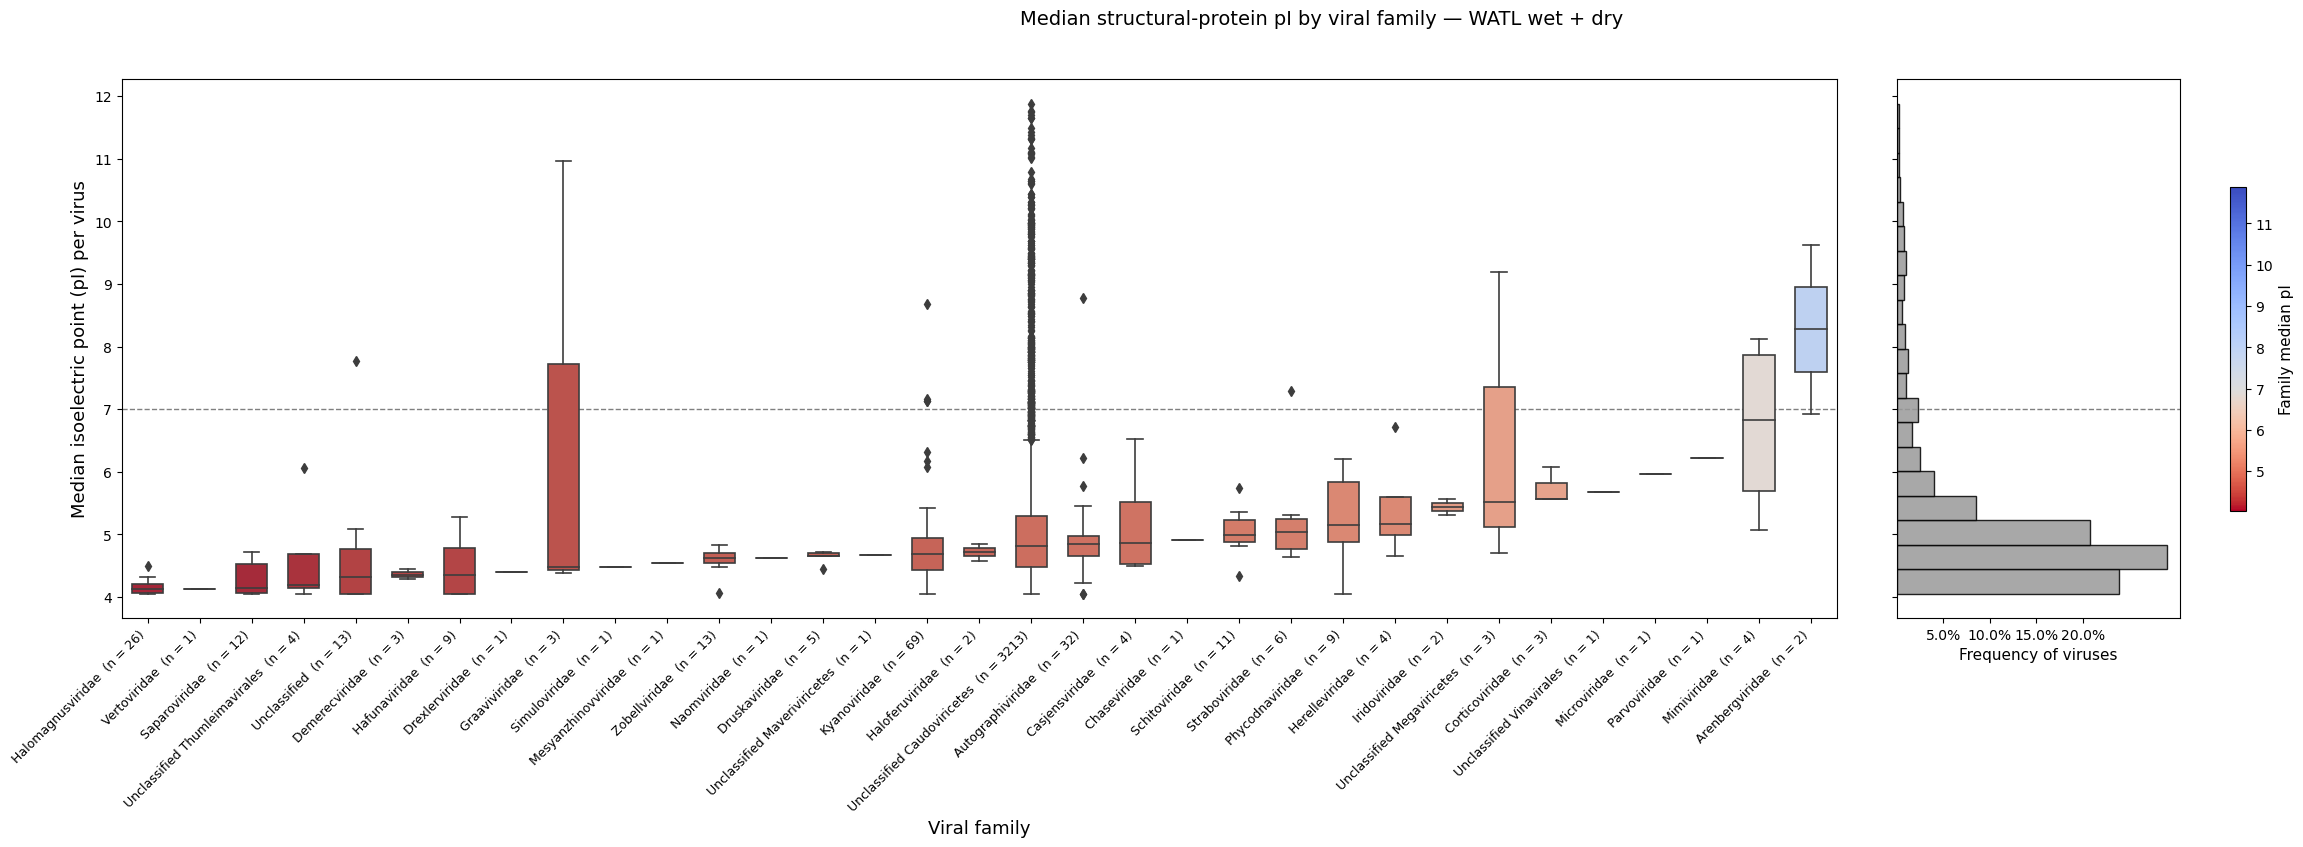

In [39]:
#  FIGURE 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.ticker import PercentFormatter

def safe_norm(vmin, vcenter, vmax):
    """Diverging norm centred at vcenter, but fall back if data is all one side."""
    if vmin < vcenter < vmax:
        return mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    return mcolors.Normalize(vmin=vmin, vmax=vmax)

med_by_fam = merged.groupby("family")["Median_pI"].median().sort_values()
print(f"Overall median pI (all viruses): {merged['Median_pI'].median():.2f}")

ordered    = med_by_fam.index.tolist()                 # families low -> high median pI
counts     = merged.groupby("family").size()           # viruses per family
cmap       = plt.cm.coolwarm_r
norm       = safe_norm(merged["Median_pI"].min(), PI_CENTER, merged["Median_pI"].max())
fam_colors = {f: cmap(norm(med_by_fam[f])) for f in ordered}

box_ratio  = max(6, len(ordered))
hist_ratio = 0.75 * max(4.5, 0.22 * box_ratio)      # <- drop the 0.75 to make it wider again
fig = plt.figure(figsize=(min(32, max(10, 0.85 * len(ordered) + 4)), 7))
gs  = fig.add_gridspec(1, 2, width_ratios=[box_ratio, hist_ratio], wspace=0.06)
ax_box  = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1], sharey=ax_box)

sns.boxplot(data=merged, x="family", y="Median_pI", order=ordered,
            showfliers=True, width=0.6, linewidth=1.2,
            palette=fam_colors, ax=ax_box)
ax_box.axhline(PI_CENTER, color="grey", ls="--", lw=1, zorder=0)
ax_box.set_xticks(range(len(ordered)))
ax_box.set_xticklabels([f"{f}  (n = {counts[f]})" for f in ordered],   # n= inline with the family name
                       rotation=45, ha="right", fontsize=9)
ax_box.set_xlabel("Viral family", fontsize=13)
ax_box.set_ylabel("Median isoelectric point (pI) per virus", fontsize=13)

n_total = len(merged)
ax_hist.hist(merged["Median_pI"], bins=20, orientation="horizontal",
             weights=np.ones(n_total) / n_total,
             color="0.6", edgecolor="black", alpha=0.85)
ax_hist.axhline(PI_CENTER, color="grey", ls="--", lw=1, zorder=0)
ax_hist.tick_params(axis="y", labelleft=False)
ax_hist.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_hist.set_xticks([0.05, 0.10, 0.15, 0.20])
ax_hist.set_xlim(0, max(0.205, ax_hist.get_xlim()[1]))   # ensure the 20% tick is shown
ax_hist.set_xlabel("Frequency of viruses", fontsize=11)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_box, ax_hist], shrink=0.6, aspect=20, pad=0.02)
cbar.set_label("Family median pI", fontsize=11)

fig.suptitle("Median structural-protein pI by viral family — WATL wet + dry", fontsize=14)
fig.savefig(FIG_FAMILY_SVG, format="svg", bbox_inches="tight")
fig.savefig(FIG_FAMILY_PNG, format="png", dpi=300, bbox_inches="tight")
print(f"families plotted: {len(ordered)}  |  total viruses: {int(counts.sum())}")
print(f"saved -> {FIG_FAMILY_SVG}\nsaved -> {FIG_FAMILY_PNG}")
plt.show()

Overall median pI (all viruses): 4.80
families plotted: 33  |  total viruses: 3462
saved -> /Users/skoog/Desktop/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_family_WATL_wet_dry_revisions_besthit.svg
saved -> /Users/skoog/Desktop/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/median_pI_by_family_WATL_wet_dry_revisions_besthit.png


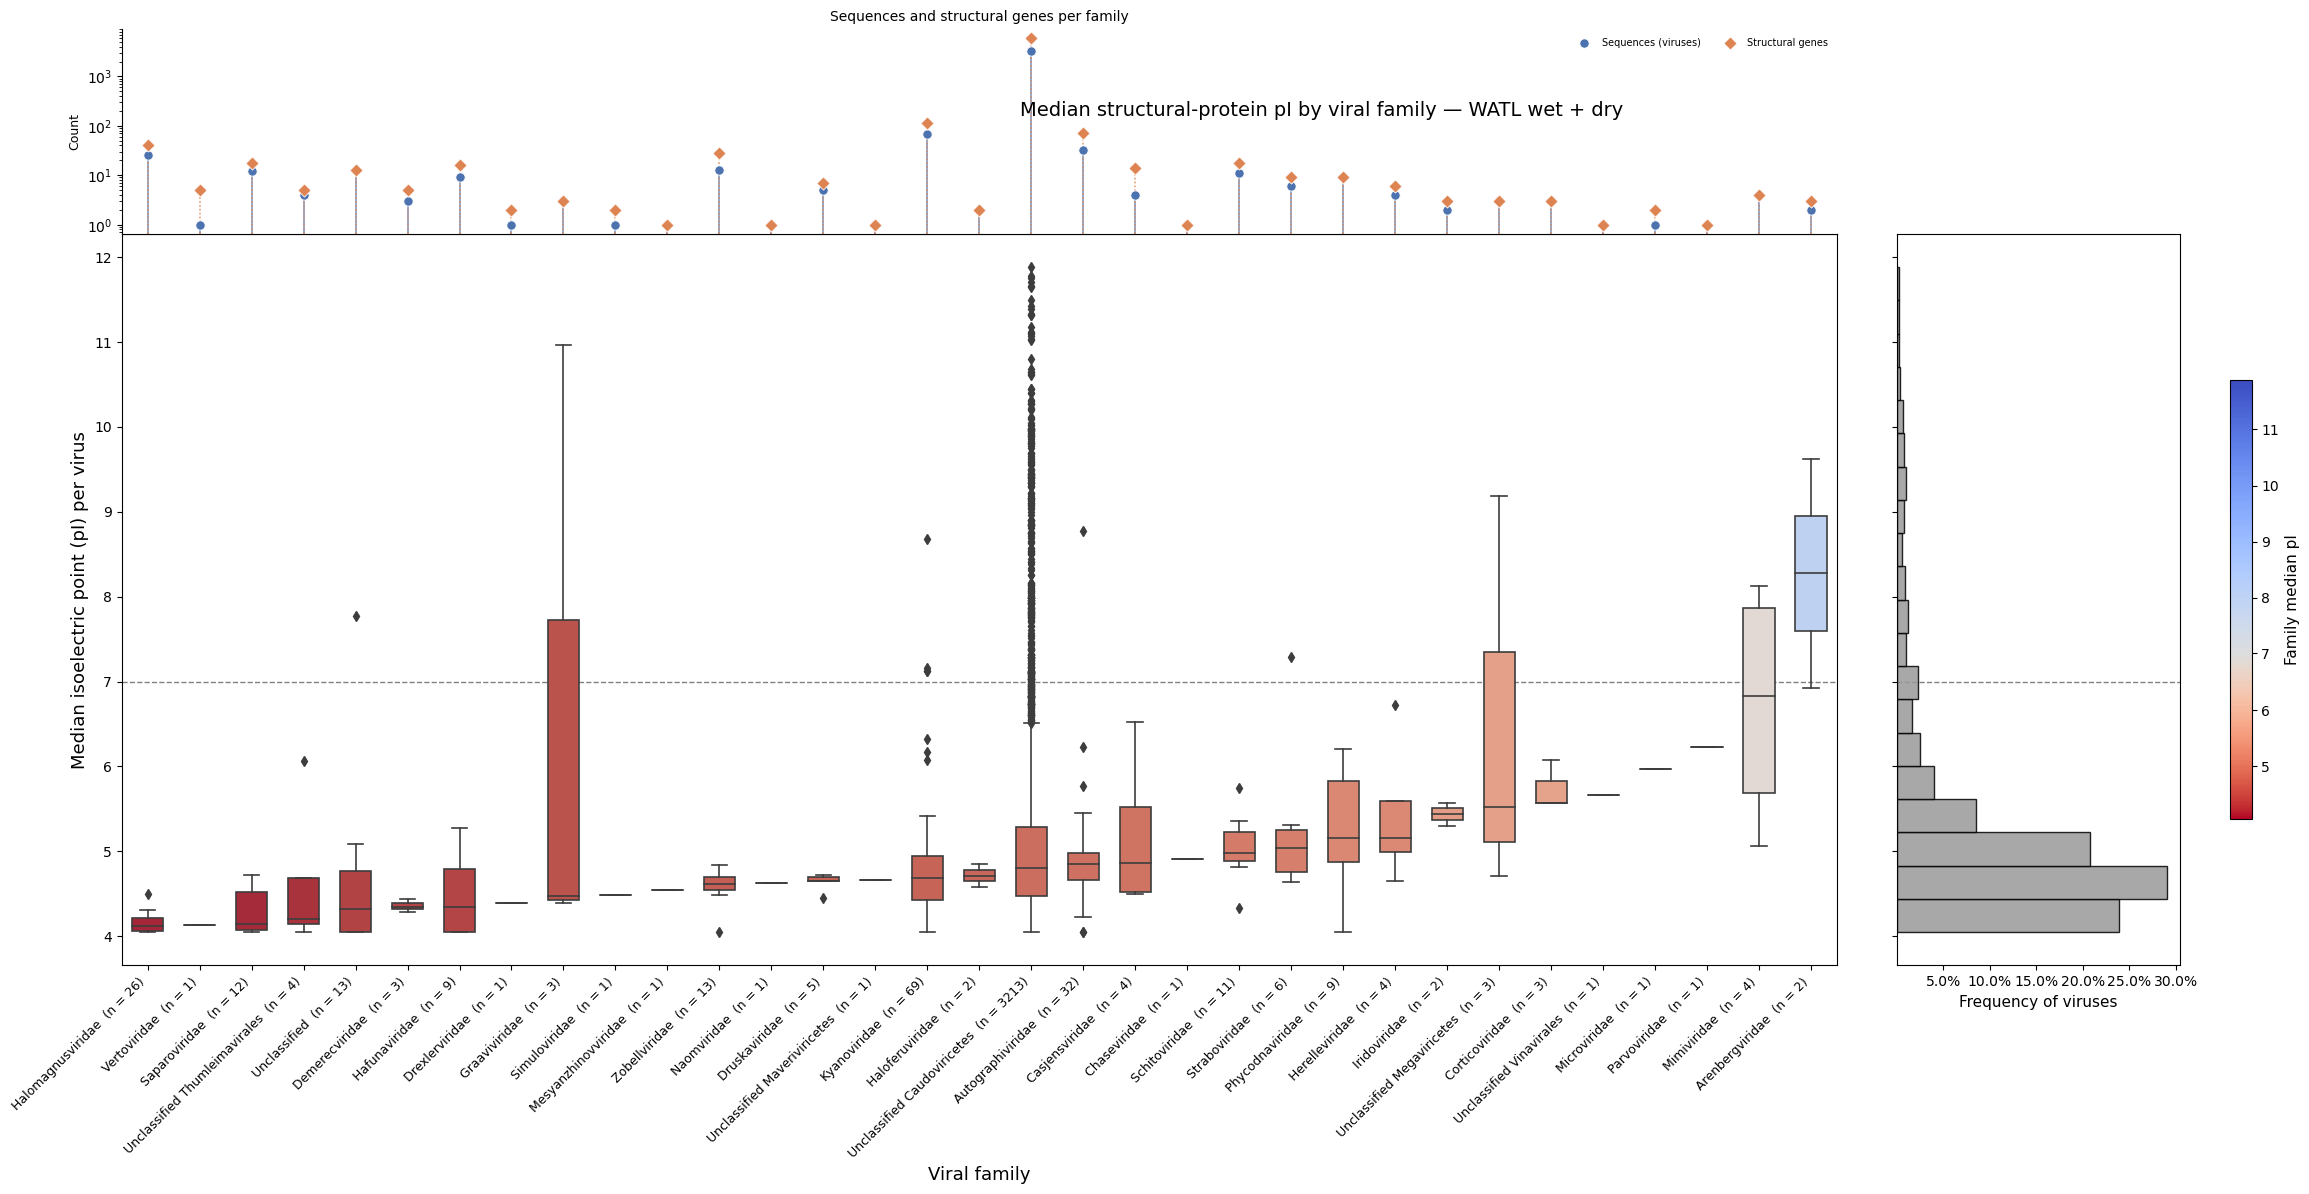

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def safe_norm(vmin, vcenter, vmax):
    if vmin < vcenter < vmax:
        return mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    return mcolors.Normalize(vmin=vmin, vmax=vmax)

med_by_fam = merged.groupby("family")["Median_pI"].median().sort_values()
print(f"Overall median pI (all viruses): {merged['Median_pI'].median():.2f}")
ordered     = med_by_fam.index.tolist()
counts      = merged.groupby("family").size()
gene_counts = merged.groupby("family")["n_structural"].sum().reindex(ordered).fillna(0).astype(int)
seq_counts  = counts.reindex(ordered).fillna(0).astype(int)

cmap       = plt.cm.coolwarm_r
norm       = safe_norm(merged["Median_pI"].min(), PI_CENTER, merged["Median_pI"].max())
fam_colors = {f: cmap(norm(med_by_fam[f])) for f in ordered}

box_ratio  = max(6, len(ordered))
hist_ratio = 0.75 * max(4.5, 0.22 * box_ratio)

fig = plt.figure(figsize=(min(32, max(10, 0.85 * len(ordered) + 4)), 9.5))
gs  = fig.add_gridspec(1, 2, width_ratios=[box_ratio, hist_ratio], wspace=0.06)

ax_box  = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1], sharey=ax_box)

#  boxplot 
sns.boxplot(data=merged, x="family", y="Median_pI", order=ordered,
            showfliers=True, width=0.6, linewidth=1.2,
            palette=fam_colors, ax=ax_box)
ax_box.axhline(PI_CENTER, color="grey", ls="--", lw=1, zorder=0)
ax_box.set_xticks(range(len(ordered)))
ax_box.set_xticklabels([f"{f}  (n = {counts[f]})" for f in ordered],
                       rotation=45, ha="right", fontsize=9)
ax_box.set_xlabel("Viral family", fontsize=13)
ax_box.set_ylabel("Median isoelectric point (pI) per virus", fontsize=13)

#top panel
ax_top = inset_axes(ax_box, width="100%", height="28%",
                     loc="lower left",
                     bbox_to_anchor=(0, 1.0, 1, 1),
                     bbox_transform=ax_box.transAxes,
                     borderpad=0)

x = np.arange(len(ordered))   

ax_top.vlines(x, 0, seq_counts.values, color="#4C72B0", lw=1.4, alpha=0.6, zorder=1)
ax_top.vlines(x, 0, gene_counts.values, color="#DD8452", lw=1.4, alpha=0.6, zorder=1, linestyle=(0, (1,1)))
ax_top.scatter(x, seq_counts.values, color="#4C72B0", s=45, zorder=3, label="Sequences (viruses)", edgecolor="white", linewidth=0.6)
ax_top.scatter(x, gene_counts.values, color="#DD8452", s=45, zorder=3, label="Structural genes", edgecolor="white", linewidth=0.6, marker="D")

ax_top.set_xlim(ax_box.get_xlim())   
ax_top.set_yscale("log")
ax_top.set_ylabel("Count", fontsize=9)
ax_top.legend(fontsize=7, frameon=False, loc="upper right", ncol=2)
ax_top.set_xticks([])
ax_top.set_title("Sequences and structural genes per family", fontsize=10)
for spine in ["top", "right"]:
    ax_top.spines[spine].set_visible(False)

# histogram 
n_total = len(merged)
ax_hist.hist(merged["Median_pI"], bins=20, orientation="horizontal",
             weights=np.ones(n_total) / n_total,
             color="0.6", edgecolor="black", alpha=0.85)
ax_hist.axhline(PI_CENTER, color="grey", ls="--", lw=1, zorder=0)
ax_hist.tick_params(axis="y", labelleft=False)
ax_hist.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_hist.set_xticks([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
ax_hist.set_xlim(0, max(0.205, ax_hist.get_xlim()[1]))
ax_hist.set_xlabel("Frequency of viruses", fontsize=11)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_box, ax_hist], shrink=0.6, aspect=20, pad=0.02)
cbar.set_label("Family median pI", fontsize=11)

fig.suptitle("Median structural-protein pI by viral family — WATL wet + dry", fontsize=14, y=1.02)
fig.savefig(FIG_FAMILY_SVG, format="svg", bbox_inches="tight")
fig.savefig(FIG_FAMILY_PNG, format="png", dpi=300, bbox_inches="tight")
print(f"families plotted: {len(ordered)}  |  total viruses: {int(counts.sum())}")
print(f"saved -> {FIG_FAMILY_SVG}\nsaved -> {FIG_FAMILY_PNG}")
plt.show()